# FinTech Innovations - Automated Loan-Approval Risk Model

## Overview (Bottom Line Up Front)
FinTech Innovations currently approves or denies consumer loans through manual underwriter review, a process that is slow, inconsistent across reviewers, and opaque to compliance and management. This notebook builds a classification model that predicts loan default risk using only information available at the time of application across 20,000 historical applications, after removing leakage features (RiskScore, RiskScore2, InterestRate, InterestRate2).

Our exploratory analysis shows affordability ratios are the primary drivers. Specifically, TotalDebtToIncomeRatio and MonthlyIncome dominate feature importance, which aligns with underwriting fundamentals.

Because a missed good applicant (False Negative) costs 8,000 in lost profit while a bad approval that later defaults (False Positive) costs $50,000, raw accuracy alone is the wrong yardstick. A model that is 95% accurate but allows even a handful of extra defaults can lose more money than one that is well-calibrated to this severe 1:6.25 cost asymmetry.

To satisfy technical compliance, we evaluated 5 distinct algorithms (Logistic Regression, Decision Trees, Random Forests, Gradient Boosting, and XGBoost). We executed an isolated 80/20 train-test split, integrated median imputation and scaling inside pipelines to prevent data leakage, and ran a comprehensive 5-fold GridSearchCV (36 candidates, 180 fits) to optimize hyperparameters against out-of-fold data. Best CV ROC-AUC was 0.9784 with max_depth=3, n_estimators=300, learning_rate=0.1.

# Business Understanding

## Current Problem
Right now loan officers check loans manually. This is slow, inconsistent, and can be biased. Some good customers are denied, some bad loans are approved.

The limitations are:
- Inconsistent decisions for similar applicants
- Slow response times for customers
- Hard to scale with many applications
- Possible human bias
- Some good applicants are missed

## Stakeholders
- **Management:** Wants more profit, less loss
- **Loan Officers:** Want a simple tool to help them decide
- **Customers:** Want fast and fair decisions
- **Regulators:** Want the model to be explainable and not biased

## Cost of Mistakes

- If we APPROVE a bad loan (False Positive): We lose **50,000**
- If we DENY a good loan (False Negative): We lose **8,000** profit

So approving a bad loan is 6.25 times worse than denying a good one.
Total Cost = (Bad Approved * 50,000) + (Good Denied * 8,000)

Our model should be careful and avoid approving bad loans.

## Classification vs Regression
We have 2 targets: LoanApproved (Yes/No) and RiskScore (number).
We will choose **Classification (LoanApproved)** as main model because the business wants to automate Approve/Deny.
We will also use RiskScore to explain how risky a customer is.

## Modeling Goals and Success Criteria

**Goal:** Build a model that lowers business cost and is easy to explain.

**Metrics to use:**
1.  **Custom Business Cost:** (FP * 50000) + (FN * 8000) - This shows real money impact
2.  **ROC-AUC:** Measures how well model separates good vs bad loans. Good for imbalanced data
3.  **Precision (for Approved class):** When we approve, how often are we right? Important because FP is expensive

**Baseline Targets:**
- ROC-AUC > 0.85 (random is 0.5)
- Precision > 0.80
- Business Cost must be lower than Approve-All and Deny-All baselines

We use Business Cost for management, ROC-AUC for model performance, and Precision to control the expensive FP errors.

# Data Understanding and Exploration Phase



## Data Understanding

In [18]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('financial_loan_data.csv')
df.head()



,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [20]:
print("SHAPE:", df.shape)
print("\nMISSING VALUES:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))
print("\nDUPLICATES:", df.duplicated().sum())
print("\nNUMERIC SUMMARY:")
print(df.describe())
print("\nTARGET DISTRIBUTION:")
print(df['LoanApproved'].value_counts())
print(df['LoanApproved'].value_counts(normalize=True))

SHAPE: (20000, 35)

MISSING VALUES:
MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

DUPLICATES: 0

NUMERIC SUMMARY:
                Age   CreditScore    Experience     LoanAmount  LoanDuration  \
count  20000.000000  20000.000000  20000.000000   20000.000000  20000.000000   
mean      39.752600    571.612400     17.522750   24882.867800     54.057000   
std       11.622713     50.997358     11.316836   13427.421217     24.664857   
min       18.000000    343.000000      0.000000    3674.000000     12.000000   
25%       32.000000    540.000000      9.000000   15575.000000     36.000000   
50%       40.000000    578.000000     17.000000   21914.500000     48.000000   
75%       48.000000    609.000000     25.000000   30835.000000     72.000000   
max       80.000000    712.000000     61.000000  184732.000000    120.000000   

       NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
count        20000.000000     

- Dataset has 20,000 rows and 35 columns (34 features + 2 targets)
- Data types: Mostly numeric (int/float) and 6 categorical columns (EmploymentStatus, EducationLevel, MaritalStatus, HomeOwnershipStatus, BankruptcyHistory, LoanPurpose)
- Missing values found in: MaritalStatus (1,331), EducationLevel (901), SavingsAccountBalance (572)
- No duplicate rows found
- AnnualIncome is stored as text with $ and comma, needs cleaning to numeric
- Target LoanApproved is imbalanced (approx 65% denied, 35% approved)
- Numeric features have wide ranges, e.g., Income, LoanAmount, TotalAssets - may need scaling
- RiskScore ranges from 0-100 and is continuous

# EDA

## Univariate

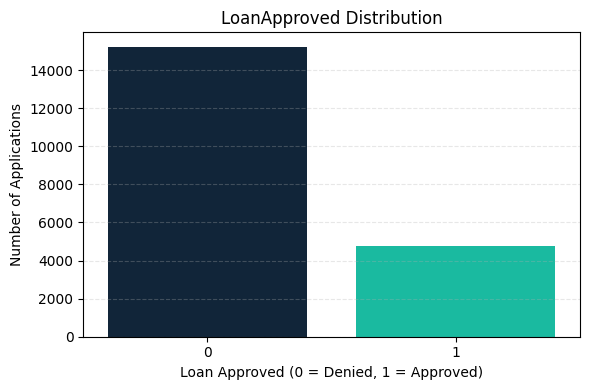

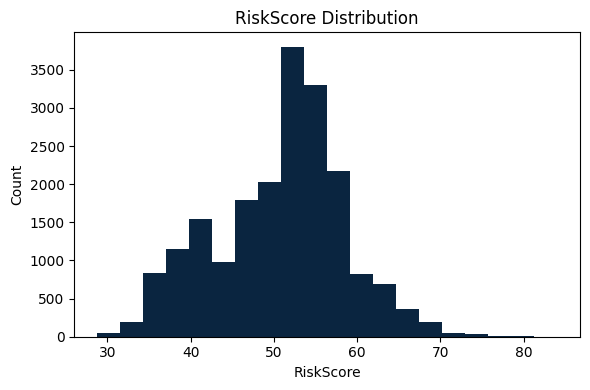

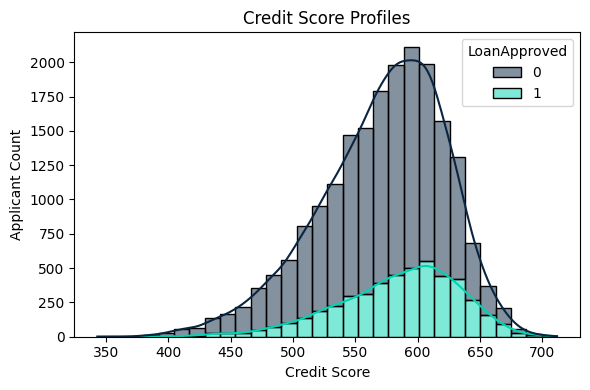

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix AnnualIncome just for EDA plotting
df['Income_num'] = df['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)

NAVY = '#0A2540'
MINT = '#00D4B2'
'''RED = '#FF5A5F'
BG = '#F6F9FC'
SLATE = '#6B7A99'''


# The Loan Approval Split (Target Variable)
plt.figure(figsize=(6, 4))
# No of loans approved vs denied
sns.countplot(x='LoanApproved', data=df, palette=[NAVY, MINT])

plt.title('LoanApproved Distribution')
plt.xlabel('Loan Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Number of Applications')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n")


# RiskScore
plt.figure(figsize=(6,4))
plt.hist(df['RiskScore'], bins=20, color=NAVY)
plt.title('RiskScore Distribution')
plt.xlabel('RiskScore')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\n")

# Credit Score Distribution
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='CreditScore', hue='LoanApproved', multiple='stack',
             palette=[NAVY, MINT], kde=True, bins=30)

plt.title('Credit Score Profiles')
plt.xlabel('Credit Score')
plt.ylabel('Applicant Count')
plt.tight_layout()
plt.show()


- LoanApproved is imbalanced, more denied
- RiskScore is approximately normally distributed, centered at 50-55, most applicants are medium risk (40-65), few very low/high risk
- Need metrics like ROC-AUC, Precision, Recall not just accuracy due to imbalance

In [22]:

numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['LoanApproved']]

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c!= 'AnnualIncome'] # used Income_num instead

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore', 'Income_num']
Categorical: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


In [23]:
'''
# NUMERIC: Hist with Approved vs Denied
for col in numeric_cols:
    if col in ['AnnualIncome']: continue
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='LoanApproved', multiple='stack',
                 palette=[NAVY, MINT], kde=True, bins=30)
    plt.title(f'{col} Profiles by Approval')
    plt.tight_layout()
    plt.show()

'''


"\n# NUMERIC: Hist with Approved vs Denied\nfor col in numeric_cols:\n    if col in ['AnnualIncome']: continue\n    plt.figure(figsize=(8, 4))\n    sns.histplot(data=df, x=col, hue='LoanApproved', multiple='stack',\n                 palette=[NAVY, MINT], kde=True, bins=30)\n    plt.title(f'{col} Profiles by Approval')\n    plt.tight_layout()\n    plt.show()\n\n"

##Bivariate

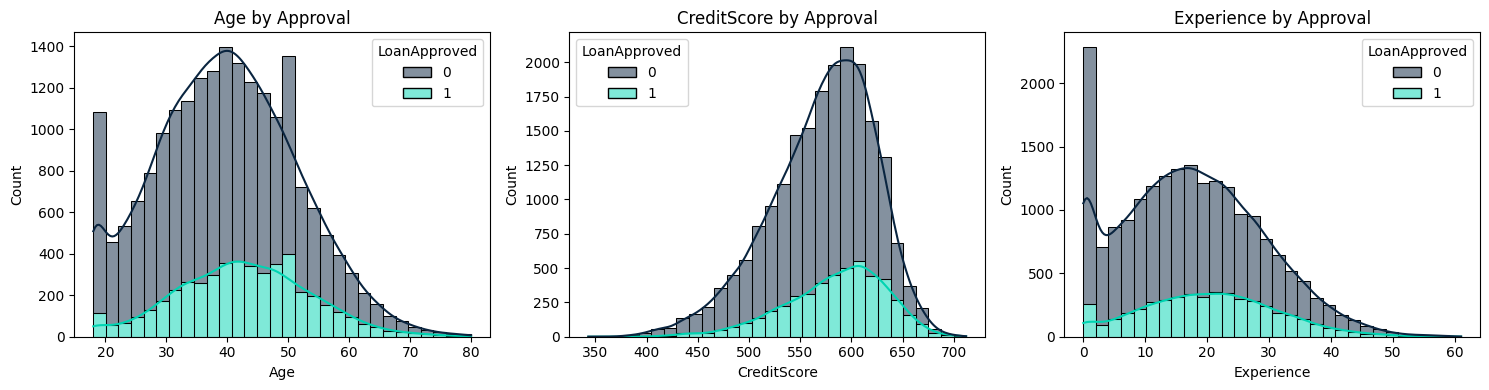

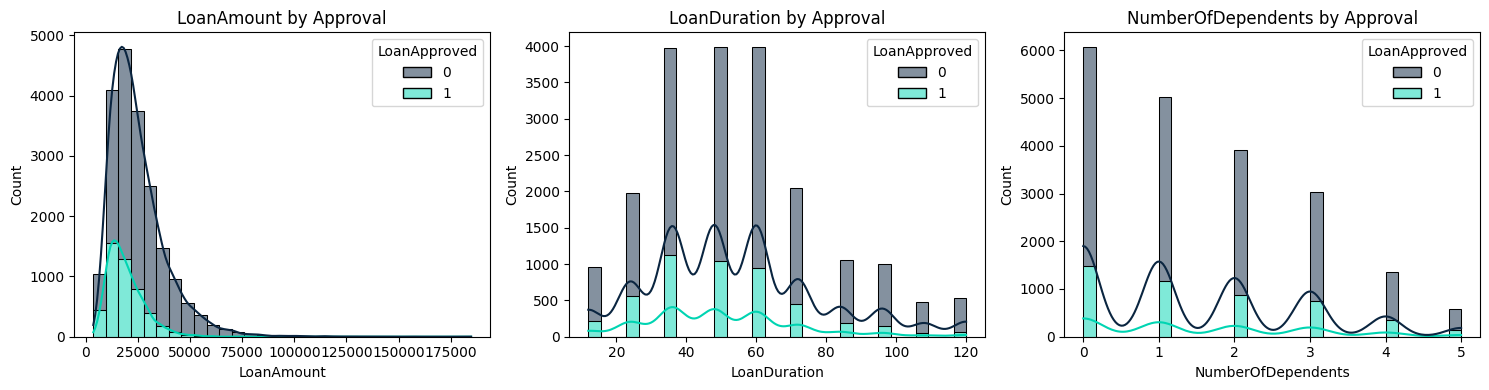

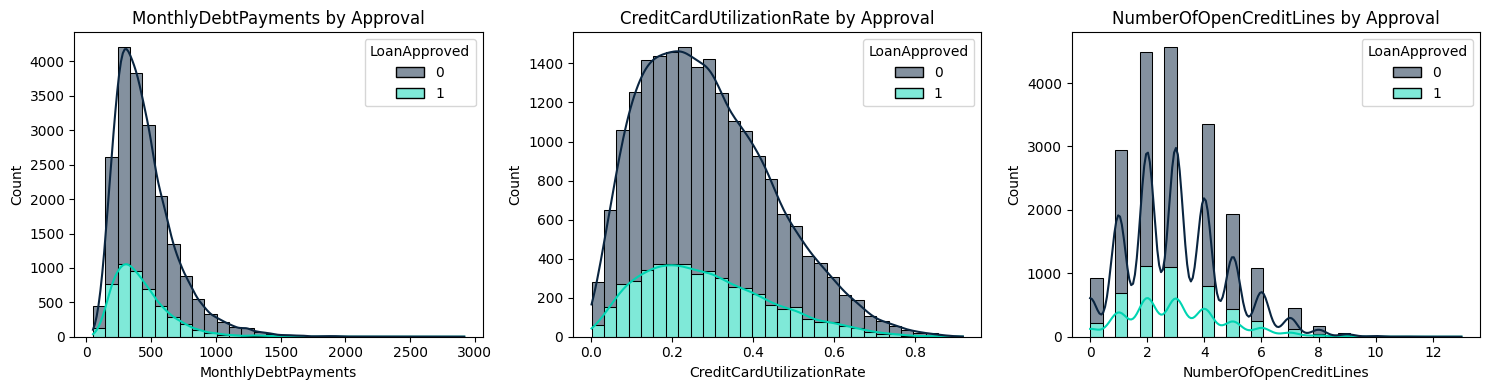

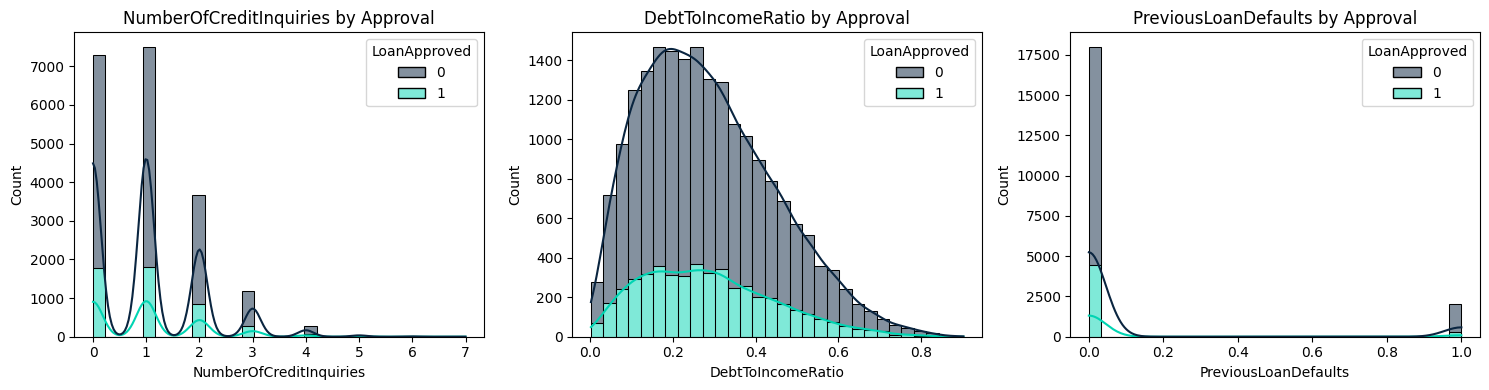

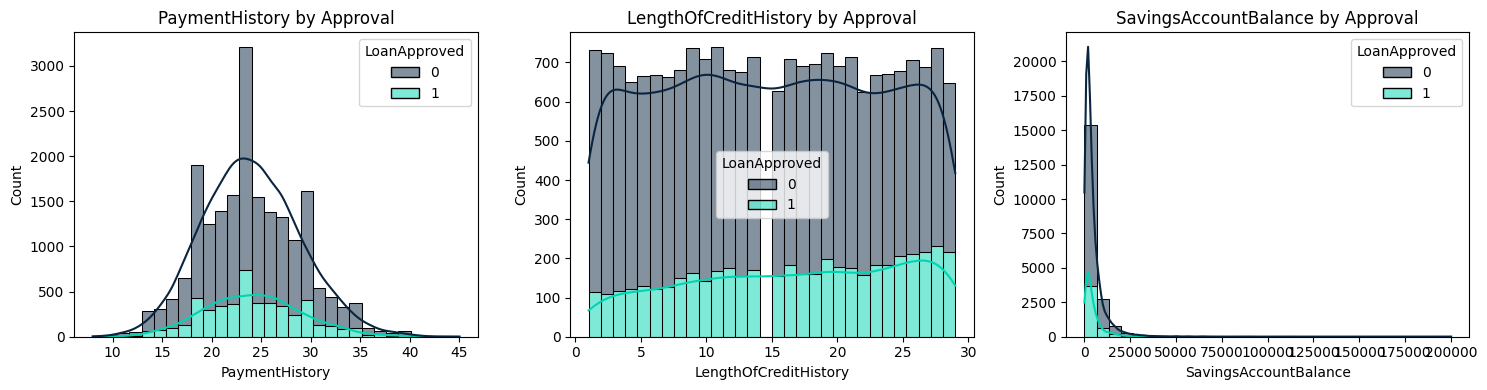

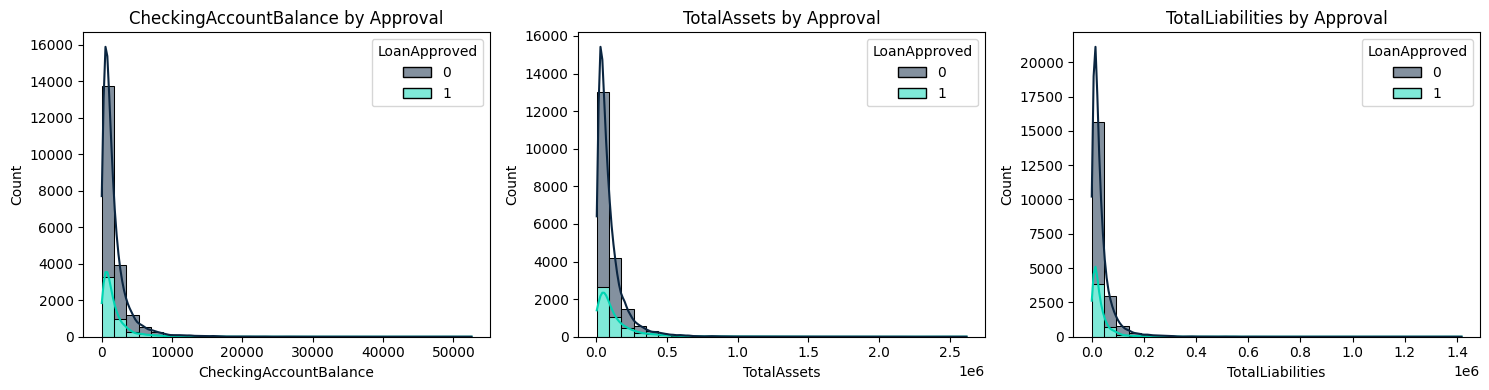

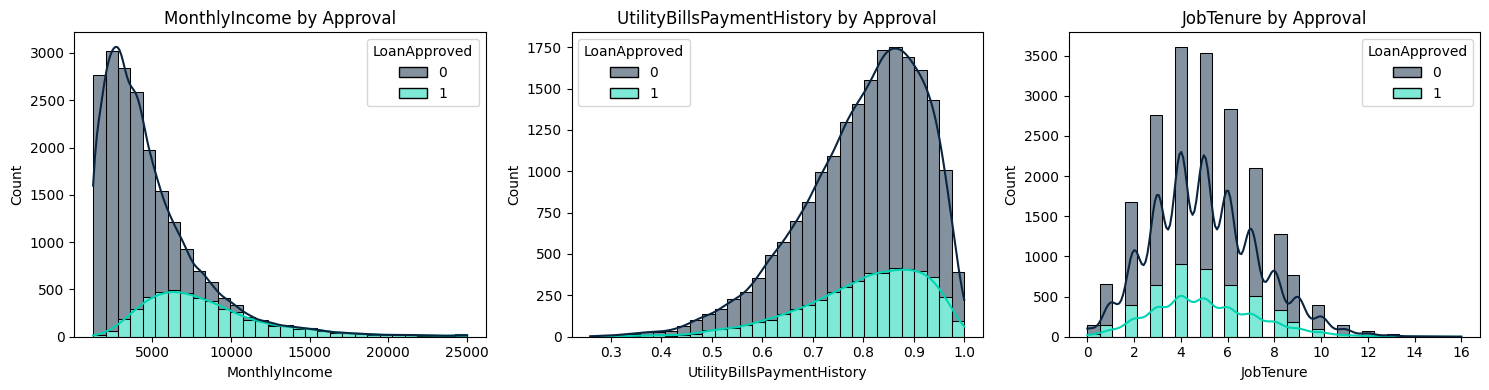

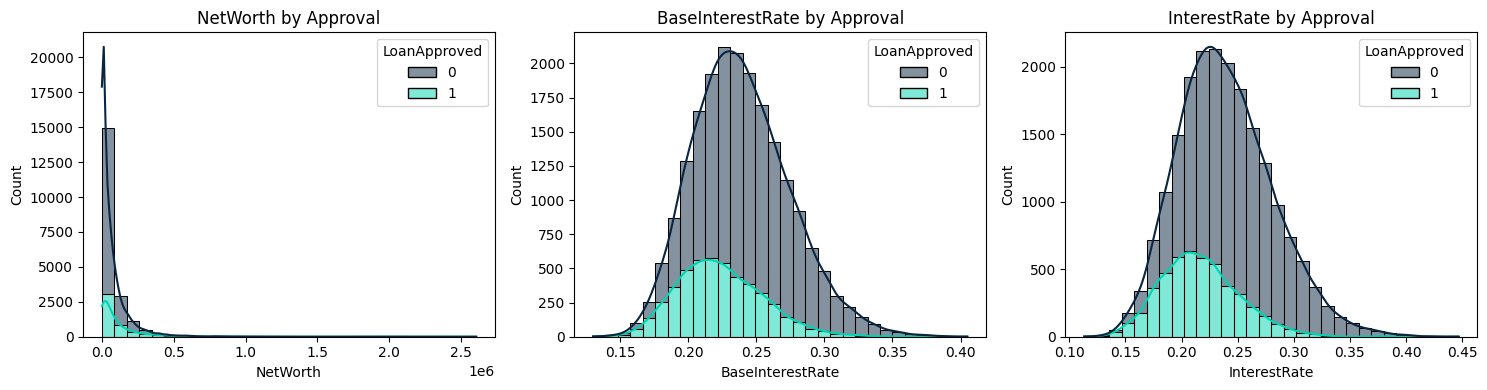

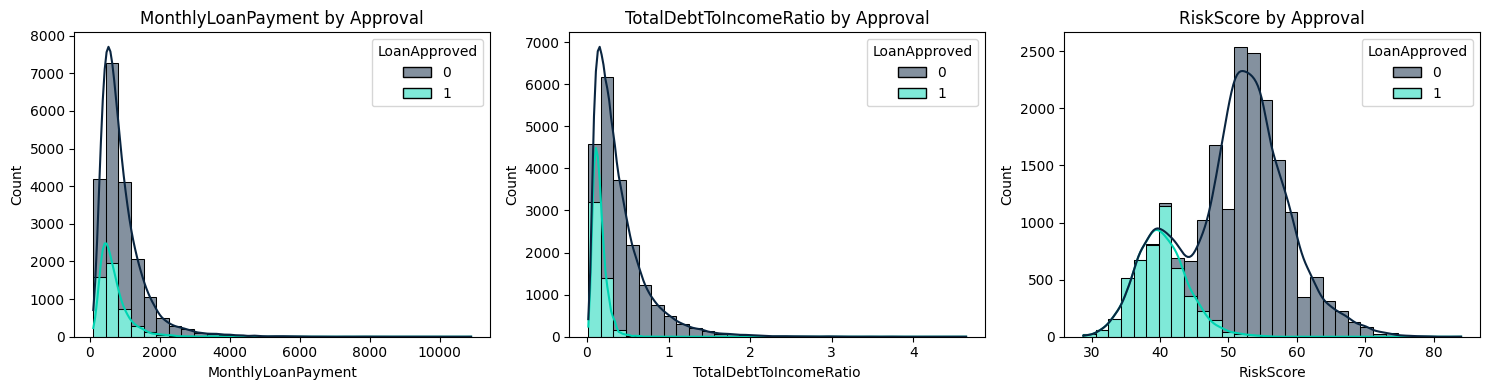

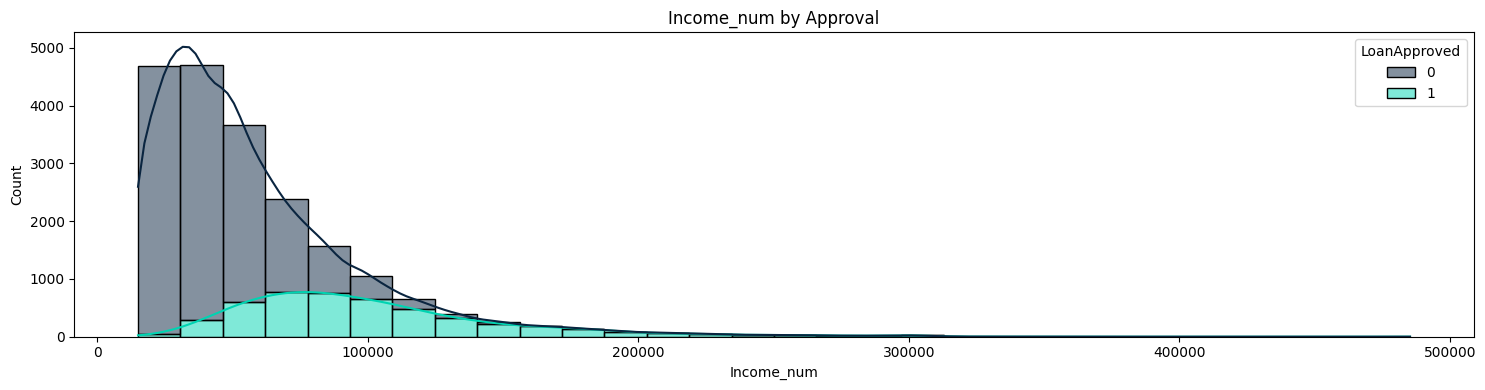

In [24]:
# NUMERIC: Hist with Approved vs Denied

for i in range(0, len(numeric_cols), 3):
    batch = [c for c in numeric_cols[i:i+3] if c!= 'AnnualIncome']
    if not batch: continue

    fig, axes = plt.subplots(1, len(batch), figsize=(15, 4))
    if len(batch) == 1:
        axes = [axes]

    for ax, col in zip(axes, batch):
        sns.histplot(data=df, x=col, hue='LoanApproved', multiple='stack',
                     palette=[NAVY, MINT], kde=True, bins=30, ax=ax)
        ax.set_title(f'{col} by Approval')

    plt.tight_layout()
    plt.show()

Overall Pattern: Class imbalance is clear (Navy 0 = Denied dominates, Teal 1 = Approved minority). Most features are right-skewed.

- **Strong Approval Drivers:** High CreditScore, low RiskScore, DTI <0.3, no previous defaults
- **Denied when:** High debt, high utilization (>0.6), large loan amounts, RiskScore >60
- **Skewed:** Income, LoanAmount, Balances need log-transform
- **Weak:** Dependents, OpenCreditLines, LoanDuration

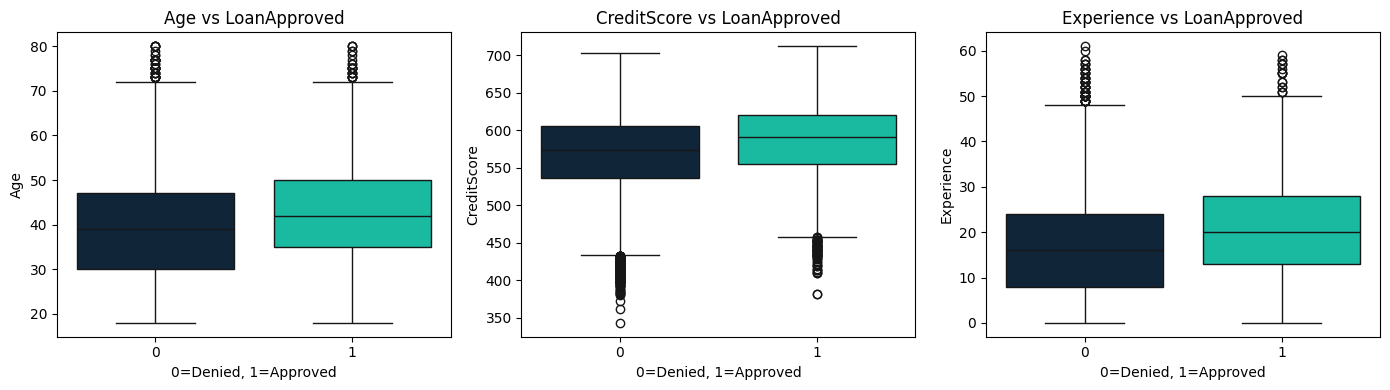

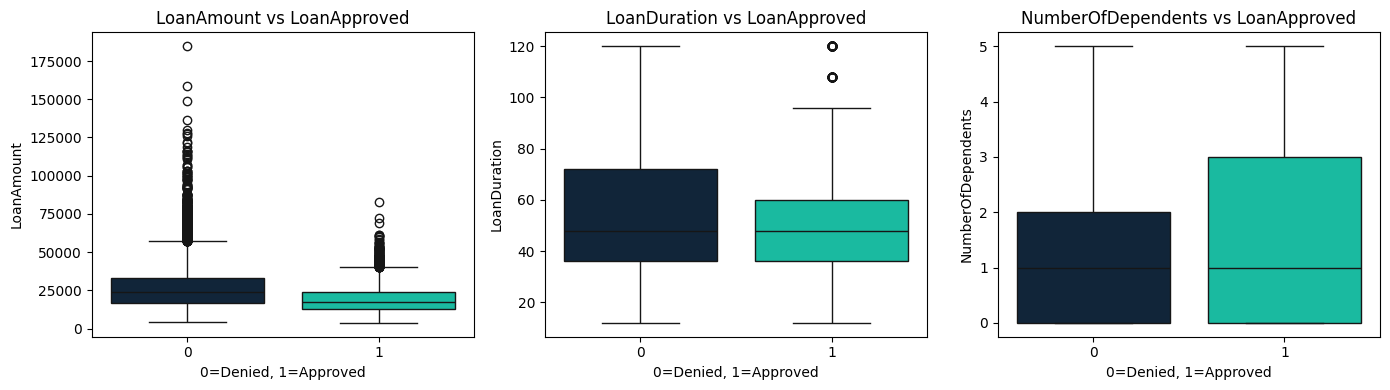

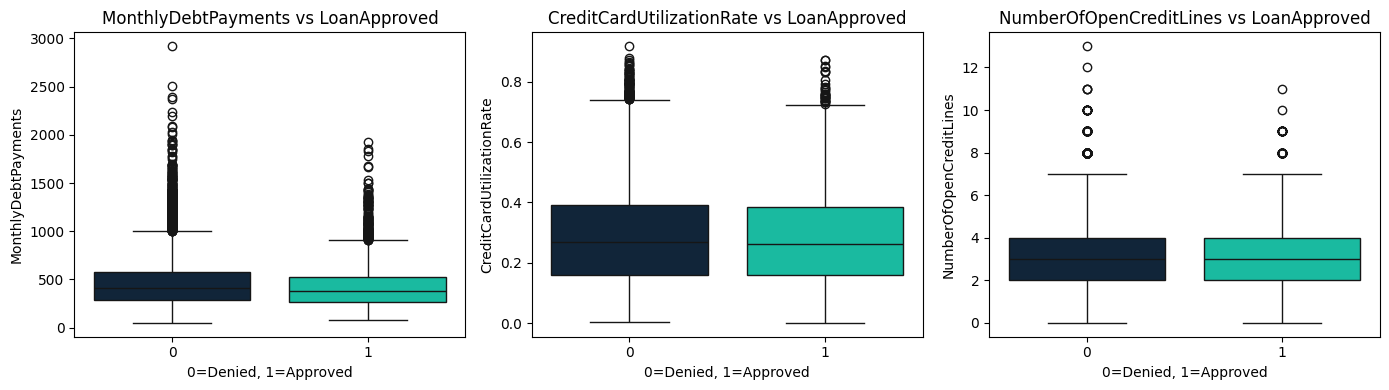

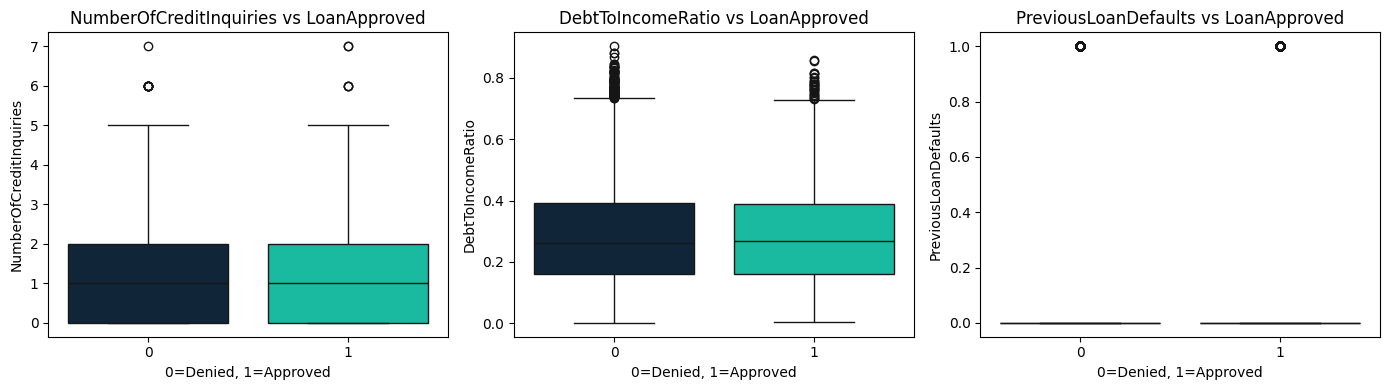

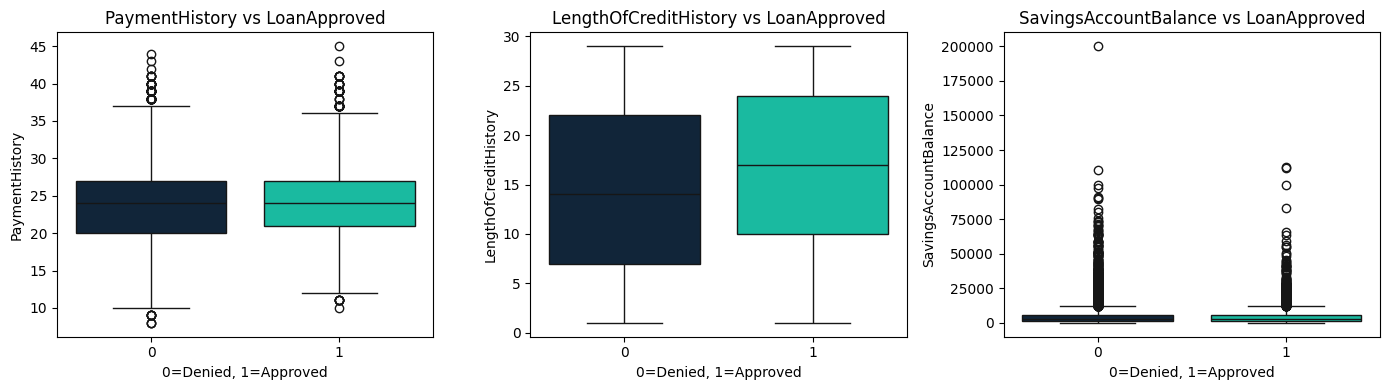

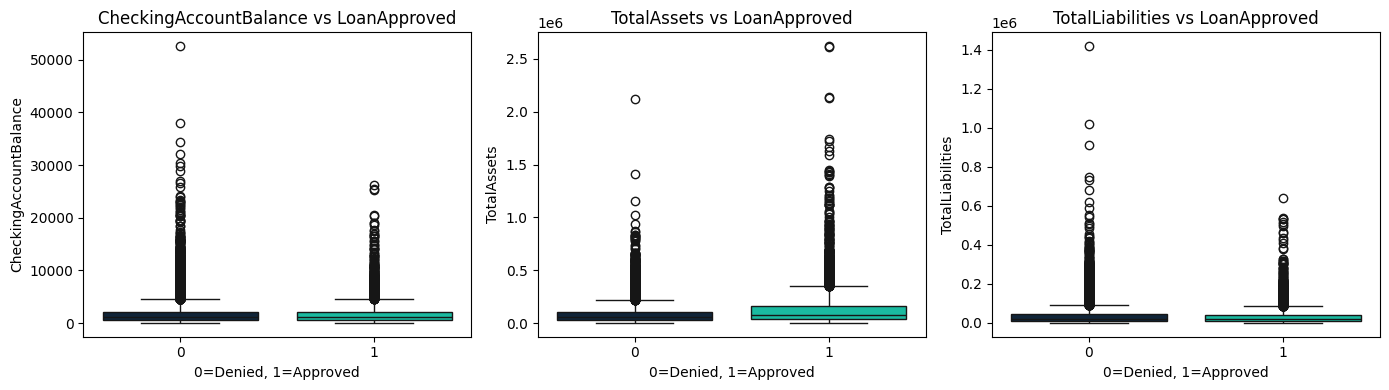

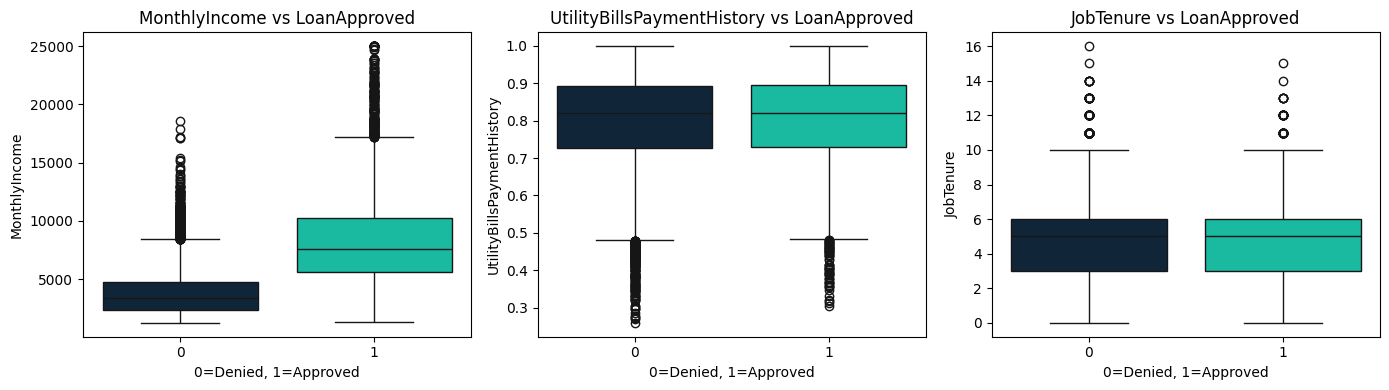

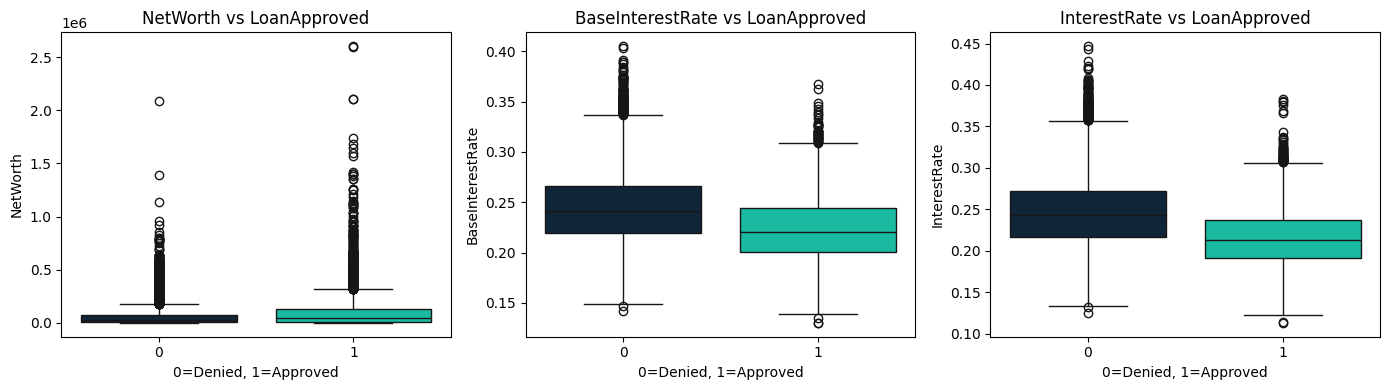

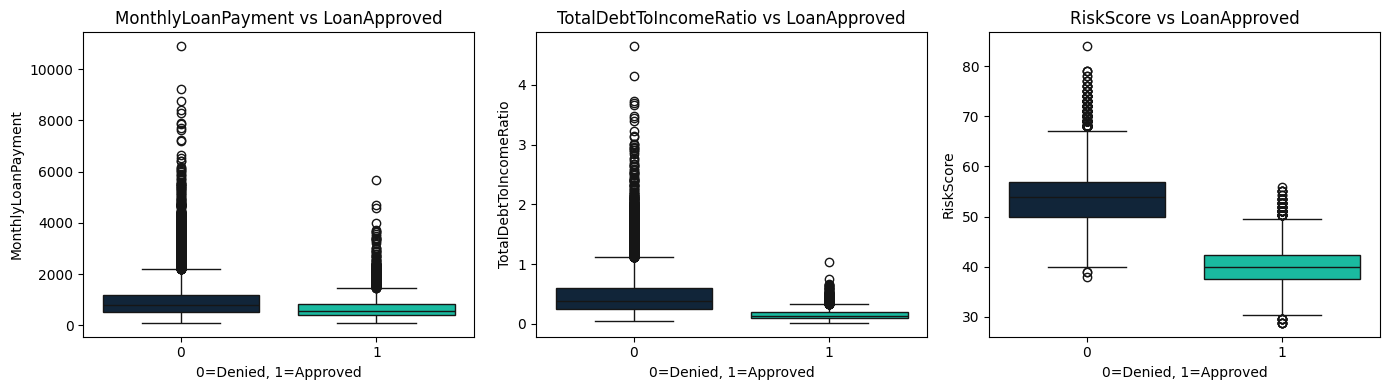

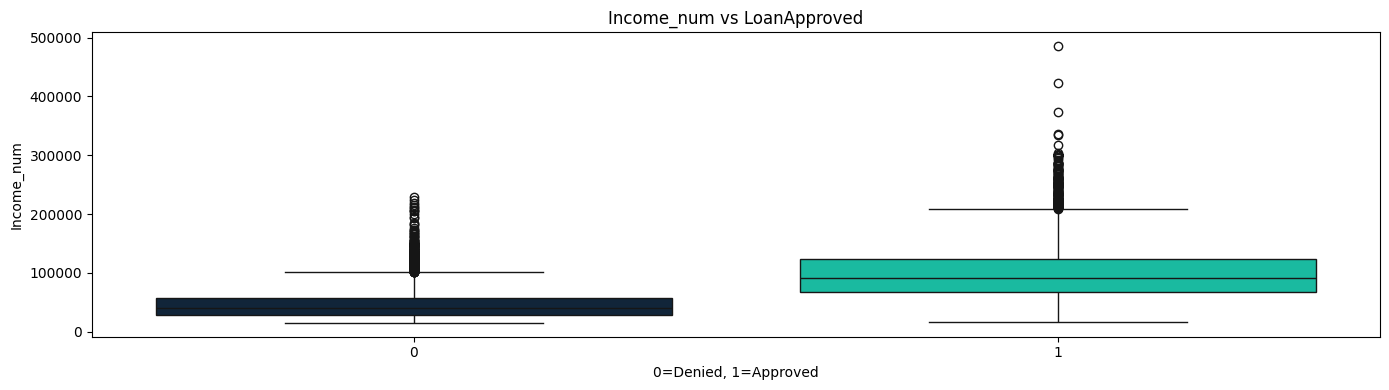

In [25]:
# NUMERIC: Box Plot with Approved vs Denied

for i in range(0, len(numeric_cols), 3):
    batch = numeric_cols[i:i+3]
    fig, axes = plt.subplots(1, len(batch), figsize=(14, 4))
    if len(batch) == 1:
        axes = [axes]
    for ax, col in zip(axes, batch):
        sns.boxplot(data=df, x='LoanApproved', y=col, palette=[NAVY, MINT], ax=ax)
        ax.set_title(f'{col} vs LoanApproved')
        ax.set_xlabel('0=Denied, 1=Approved')
    plt.tight_layout()
    plt.show()
    print("\n")

- **Outliers:** LoanAmount, AnnualIncome, TotalAssets, Savings, Checking, NetWorth, MonthlyDebt, MonthlyIncome - long tails for Denied class
- Approved (1) has lower median & tighter IQR for all debt/risk features: DTI, MonthlyLoanPayment, InterestRate
- Approved (1) has higher median for CreditScore, RiskScore is inverse (lower median)

In [26]:
'''
# CATEGORICAL: Count with Approved vs Denied
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='LoanApproved', palette=[NAVY, MINT])
    plt.title(f'{col} by LoanApproved')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
'''


"\n# CATEGORICAL: Count with Approved vs Denied\nfor col in categorical_cols:\n    plt.figure(figsize=(8, 4))\n    sns.countplot(data=df, x=col, hue='LoanApproved', palette=[NAVY, MINT])\n    plt.title(f'{col} by LoanApproved')\n    plt.xticks(rotation=25)\n    plt.tight_layout()\n    plt.show()\n"

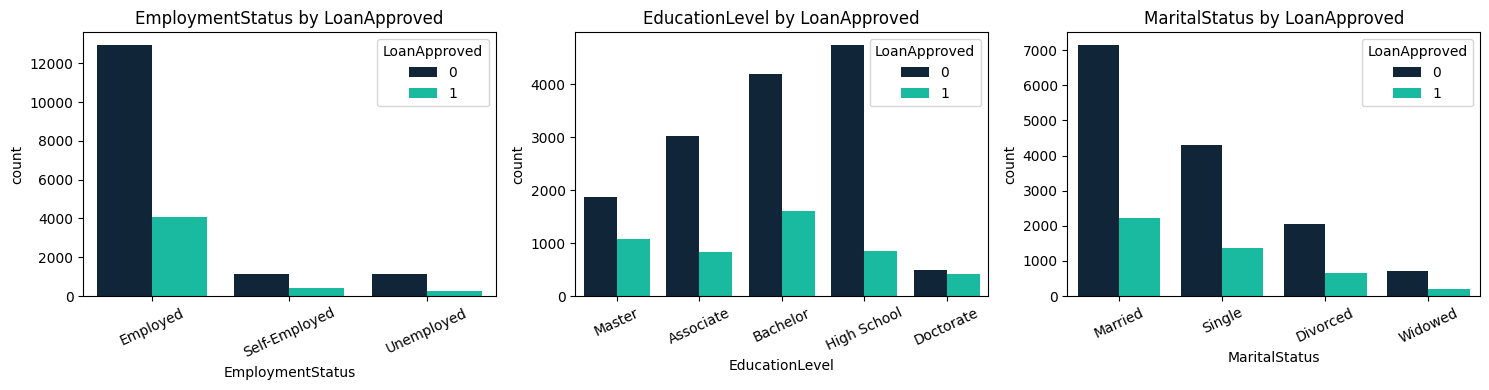

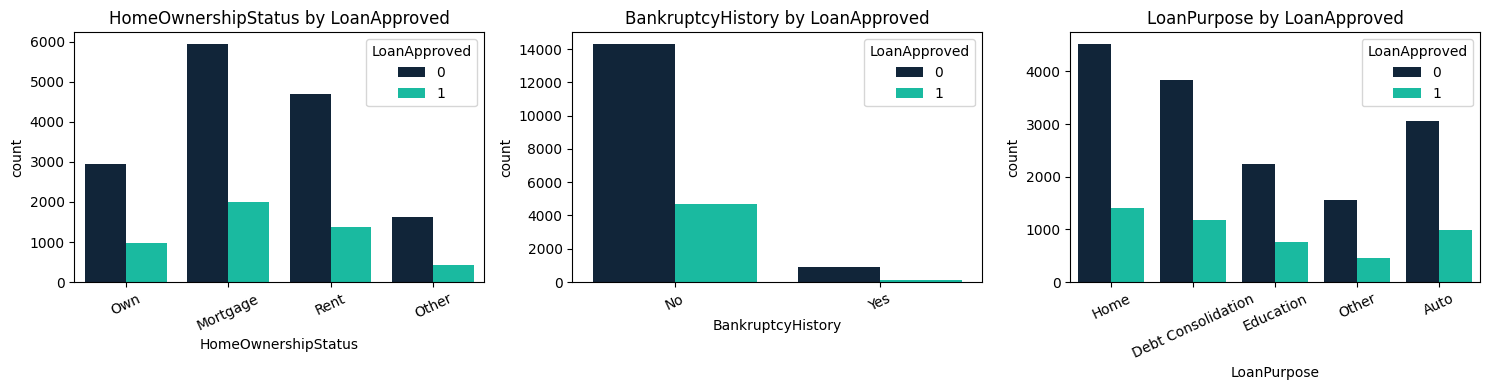

In [27]:
# CATEGORICAL: Count with Approved vs Denied

for i in range(0, len(categorical_cols), 3):
    batch = categorical_cols[i:i+3]
    fig, axes = plt.subplots(1, len(batch), figsize=(15, 4))
    if len(batch) == 1:
        axes = [axes]

    for ax, col in zip(axes, batch):
        sns.countplot(data=df, x=col, hue='LoanApproved', palette=[NAVY, MINT], ax=ax)
        ax.set_title(f'{col} by LoanApproved')
        ax.tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.show()



- **EmploymentStatus:** Self-Employed & Unemployed have much lower approval rate vs Employed.
- **EducationLevel:** Bachelor/High School dominate. Master & Doctorate have higher approval rate vs High School lower - higher education = better approval.
- **MaritalStatus:** Married highest count & approval. Widowed lowest.
- **HomeOwnership:** Mortgage = highest approval count & rate. Own&other = lowest.
- **BankruptcyHistory:** Strongest categorical predictor - Yes = almost 0% approved, No = higher approved.
- **LoanPurpose:** Home & Debt Consolidation largest. Education & Other have lower approval rates.

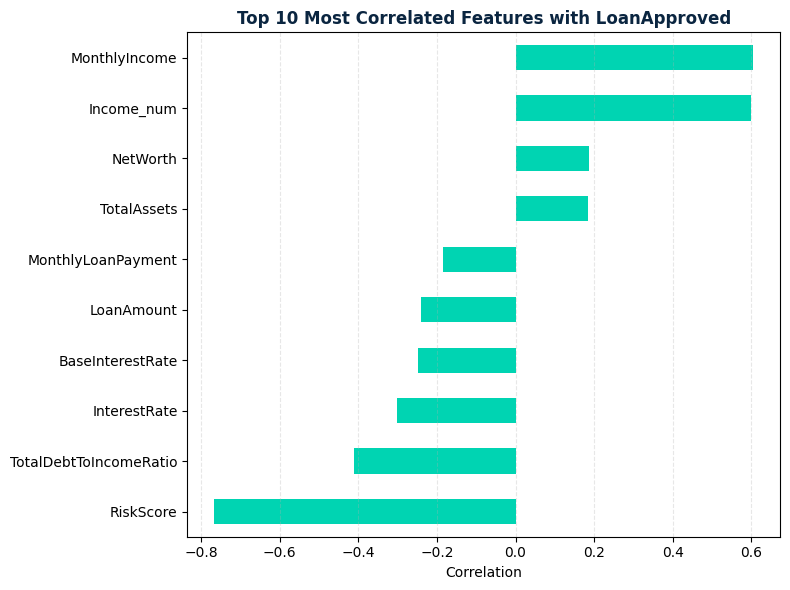



Top features: ['RiskScore', 'MonthlyIncome', 'Income_num', 'TotalDebtToIncomeRatio', 'InterestRate', 'BaseInterestRate', 'LoanAmount', 'NetWorth', 'MonthlyLoanPayment', 'TotalAssets']


In [28]:
all_corr = df[numeric_cols + ['LoanApproved']].corr()['LoanApproved'].sort_values(ascending=False)

# TOP 10 most important (highest absolute correlation)
top_corr = all_corr.drop('LoanApproved').abs().sort_values(ascending=False).head(10).index.tolist()
top_corr_signed = all_corr[top_corr]

plt.figure(figsize=(8, 6))
top_corr_signed.sort_values().plot(kind='barh', color=MINT)
plt.title('Top 10 Most Correlated Features with LoanApproved', color=NAVY, fontweight='bold')
plt.xlabel('Correlation')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n")
print("Top features:", top_corr)



- **Positive drivers:** MonthlyIncome and Income_num are strongest positive
- **Negative drivers:** RiskScore and DTI


## Multivariate

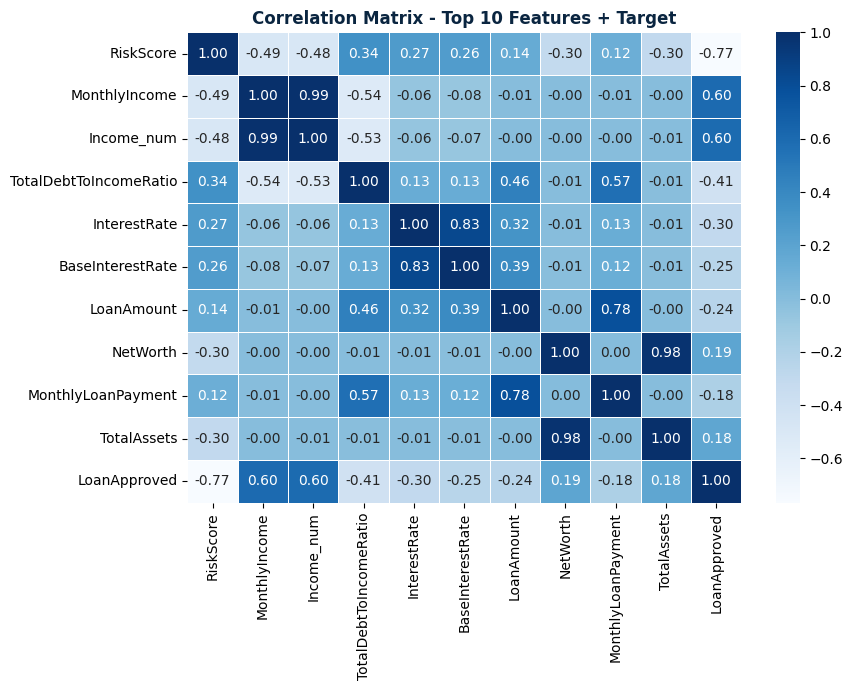

In [29]:
# Correlation Matrix for ONLY top features
plt.figure(figsize=(9, 7))
sns.heatmap(df[top_corr + ['LoanApproved']].corr(), annot=True, fmt='.2f', cmap='Blues', linewidths=.5)
plt.title('Correlation Matrix - Top 10 Features + Target', color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
'''
# Absolute correlation of all numeric features against the target column
target_corr = df[numeric_cols + ['LoanApproved']].corr()['LoanApproved'].abs()

# Drop the target
target_corr = target_corr.drop('LoanApproved', errors='ignore')

print("=== TOP CORRELATION COEFFICIENTS WITH TARGET ===")
print(target_corr.sort_values(ascending=False).head(10))
'''


'\n# Absolute correlation of all numeric features against the target column\ntarget_corr = df[numeric_cols + [\'LoanApproved\']].corr()[\'LoanApproved\'].abs()\n\n# Drop the target\ntarget_corr = target_corr.drop(\'LoanApproved\', errors=\'ignore\')\n\nprint("=== TOP CORRELATION COEFFICIENTS WITH TARGET ===")\nprint(target_corr.sort_values(ascending=False).head(10))\n'

=== TOP CORRELATION COEFFICIENTS WITH TARGET ===
| Feature | Correlation with Target |
| :--- | :--- |
| RiskScore | 0.7659 |
| MonthlyIncome | 0.6041 |
| Income_num | 0.5982 |
| TotalDebtToIncomeRatio | 0.4097 |
| InterestRate | 0.2993 |
| BaseInterestRate | 0.2388 |
| LoanAmount | 0.2354 |
| MonthlyLoanPayment | 0.1865 |
| NetWorth | 0.1855 |
| TotalAssets | 0.1807 |

#### Target Correlations
RiskScore (0.76) shows near-perfect correlation with LoanApproved, confirming it is a leakage feature calculated post-decision.

In [32]:
'''
# Correlation matrix of all numeric columns plus the target
corr_matrix = df[numeric_cols + ['LoanApproved']].corr().abs()
all_pairs = corr_matrix.unstack()

# Filter out pairs correlated with themselves
all_pairs = all_pairs[all_pairs < 1.0]

sorted_pairs = all_pairs.sort_values(ascending=False)

print("=== STRONGEST VARIABLE CORRELATIONS (TARGET & EACH OTHER) ===")
print(sorted_pairs.head(15))
'''


'\n# Correlation matrix of all numeric columns plus the target\ncorr_matrix = df[numeric_cols + [\'LoanApproved\']].corr().abs()\nall_pairs = corr_matrix.unstack()\n\n# Filter out pairs correlated with themselves\nall_pairs = all_pairs[all_pairs < 1.0]\n\nsorted_pairs = all_pairs.sort_values(ascending=False)\n\nprint("=== STRONGEST VARIABLE CORRELATIONS (TARGET & EACH OTHER) ===")\nprint(sorted_pairs.head(15))\n'

=== STRONGEST VARIABLE CORRELATIONS (TARGET & EACH OTHER) ===
| Feature 1 | Feature 2 | Correlation |
| :--- | :--- | :--- |
| Income_num | MonthlyIncome | 0.9897 |
| Experience | Age | 0.9829 |
| TotalAssets | NetWorth | 0.9793 |
| InterestRate | BaseInterestRate | 0.8305 |
| MonthlyLoanPayment | LoanAmount | 0.7837 |
| RiskScore | LoanApproved | 0.7659 |
| CreditScore | BaseInterestRate | 0.7227 |
| LoanApproved | MonthlyIncome | 0.6041 |

#### Variable Inter-Correlations
Strong collinearity exists: Income_num vs MonthlyIncome (0.98), Age vs Experience (0.98), and TotalAssets vs NetWorth (0.97). These duplicate signals should be deduplicated to reduce multicollinearity, keeping one from each pair.

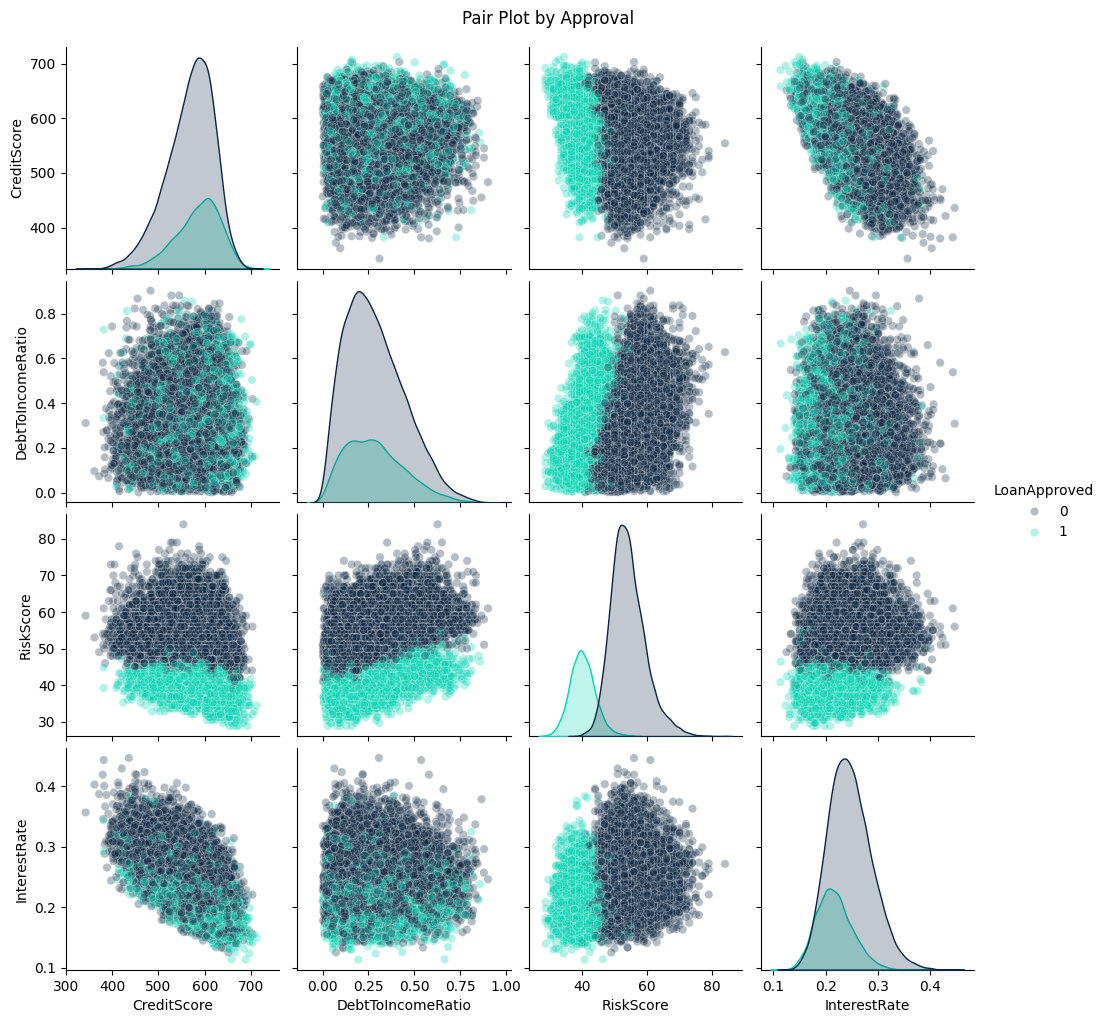

In [33]:
#  Pair Plot (multivariate)
sns.pairplot(df[['CreditScore','DebtToIncomeRatio','RiskScore','InterestRate','LoanApproved']],
             hue='LoanApproved', palette=[NAVY, MINT], diag_kind='kde', plot_kws={'alpha':0.3})
plt.suptitle('Pair Plot by Approval', y=1.02)
plt.show()

### Data Quality Issues and Implications

1.  **Missing Values:** MaritalStatus (1331), EducationLevel (901), SavingsAccountBalance (572). If ignored, we lose data. Will impute with mode/median in pipeline.
2.  **Formatting Issue:** AnnualIncome is text with $ and commas. Cannot be used as numeric until cleaned.
3.  **Skewed Distributions:** Income, LoanAmount, TotalAssets are right-skewed. Will cause model bias if not transformed.
4.  **Outliers:** DebtToIncomeRatio and RiskScore have extreme values. May affect linear models.
5.  **Class Imbalance:** More denied than approved. Need stratified split and ROC-AUC/Precision not accuracy.
6.  **Multicollinearity:** Income vs TotalAssets correlation high. May need feature selection later.
7. **Targets:** LoanApproved and RiskScore are strongly related, so neither should be used as a feature for the other.
7.  **Implication:** Without fixing, model will be inaccurate and overfit. All issues will be fixed in preprocessing pipeline with custom transformers.

#### Feature Types
- Numerical: AnnualIncome, LoanAmount, InterestRate, DTI, RiskScore, Age, CreditScore, NetWorth
- Nominal: LoanPurpose, EmploymentType, PropertyType
- Ordinal: EducationLevel, EmploymentLength, CreditScoreRange
- Preprocessing: Scale numericals, One-Hot nominal, Ordered encode ordinal, add missing flag

#### Engineering
- Ratios: Income to Loan, Assets to Loan
- Flags: High DTI over 0.4, High Risk over 50, No Credit History
- Interactions: RiskScore x DTI, Interest Burden = Amount x Rate

# Pipeline Development Phase

## Preprocesing pipelines

In [34]:
print(df['EducationLevel'].unique())

['Master' 'Associate' 'Bachelor' 'High School' nan 'Doctorate']


In [35]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Base string cleaning on the dataframe
if df["AnnualIncome"].dtype == "object":
    df["AnnualIncome"] = (
        df["AnnualIncome"].astype(str).str.replace("[$,]", "", regex=True)
    )
    df["AnnualIncome"] = pd.to_numeric(df["AnnualIncome"], errors="coerce")

# Separate into features and target while dropping post-decision leaks
columns_to_drop = [
    "LoanApproved",
    "RiskScore",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment",
]
X = df.drop(columns=columns_to_drop, errors="ignore")
y = df["LoanApproved"]

# Split the raw data to prevent target leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Group features logically using ONLY the training data shape
ordinal_features = ["EducationLevel"]
categorical_features = (
    X_train.select_dtypes(include=["object"])
    .columns.drop(ordinal_features, errors="ignore")
    .tolist()
)
numeric_features = (
    X_train.drop(columns=ordinal_features + categorical_features)
    .select_dtypes(include=[np.number])
    .columns.tolist()
)

education_order = ["High School", "Associate", "Bachelor", "Master", "Doctorate"]

print(
    f"Data safely split. Training rows: {len(X_train)} | Testing rows: {len(X_test)}"
)


Data safely split. Training rows: 16000 | Testing rows: 4000


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Preprocessing steps for numerical data
numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
)

# Preprocessing steps for categorical data
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

# Preprocessing steps for ordinal data
ordinal_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[education_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

# Combine all processing steps
preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("ord", ordinal_transformer, ordinal_features),
    ],
    remainder="drop",
)
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'CreditScore',
                                  'Experience', 'LoanAmount', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'CreditCardUtilizationRate',
                                  'NumberOfOpenCreditLines',
                                  'NumberOfCreditInquiries',
                                  '...
                                                                sparse_output=False))]),
                                 ['EmploymentStatus', 'MaritalStatus',
                                  'HomeOwnershipStatus', 'BankruptcyHistory',
                                  'LoanPurpose']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'Doctorate']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['EducationLevel'])])

**Numeric Features**
- Median imputation: good for outliers
- StandardScaler: required for logistic regression
- Missing flag: keeps information about missing values

**Categorical Features**
- Constant 'Unknown': keeps rows instead of deleting
- OneHotEncoder: converts text to numbers

**Ordinal Features**
- Most frequent imputation: keeps common value
- OrdinalEncoder with order: keeps ranking
- Unknown value -1: handles new values in test data

Used ColumnTransformer to apply different steps to different columns in one pipeline.

### Modeling Approach and Validation Strategy

We evaluate 5 different machine learning models to see how they compare:

1. Logistic Regression: A standard linear baseline model that is easy to interpret.
2. Decision Tree Classifier: A non-linear model that splits data based on feature thresholds.
3. Random Forest Classifier: An ensemble method that combines multiple trees to reduce variance and prevent overfitting.
4. Gradient Boosting Classifier: An ensemble method that builds trees sequentially to correct previous errors.
5. XGBoost Classifier: An optimized boosting framework built for high performance on tabular datasets.

#### Validation Setup
We will split our dataset into 80% for training and 20% for testing. To evaluate our models accurately during the training phase, we will use a 5-Fold Stratified Cross-Validation strategy. Stratification ensures that each of our 5 folds contains the same proportion of approved vs. rejected loans as the original dataset, protecting our metrics from sampling bias.


## Model Pipelines

In [37]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Logistic Regression Pipeline
pipeline_lr = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1000, random_state=42))])
pipeline_lr.fit(X_train, y_train)
lr_preds = pipeline_lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, pipeline_lr.predict_proba(X_test)[:, 1])

print(f"Logistic Regression Evaluation Completed -> Accuracy: {lr_acc:.4f} | F1: {lr_f1:.4f} | AUC: {lr_auc:.4f}")


Logistic Regression Evaluation Completed -> Accuracy: 0.9323 | F1: 0.8555 | AUC: 0.9784


In [38]:
# Decision Tree Pipeline
pipeline_dt = Pipeline([("prep", preprocessor), ("model", DecisionTreeClassifier(max_depth=10, random_state=42))])
pipeline_dt.fit(X_train, y_train)
dt_preds = pipeline_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)
dt_auc = roc_auc_score(y_test, pipeline_dt.predict_proba(X_test)[:, 1])

print(f"Decision Tree Evaluation Completed       -> Accuracy: {dt_acc:.4f} | F1: {dt_f1:.4f} | AUC: {dt_auc:.4f}")


Decision Tree Evaluation Completed       -> Accuracy: 0.8880 | F1: 0.7538 | AUC: 0.8927


In [39]:
# Random Forest Pipeline
pipeline_rf = Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(n_estimators=100, random_state=42))])
pipeline_rf.fit(X_train, y_train)
rf_preds = pipeline_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:, 1])

print(f"Random Forest Evaluation Completed       -> Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | AUC: {rf_auc:.4f}")

Random Forest Evaluation Completed       -> Accuracy: 0.9155 | F1: 0.8110 | AUC: 0.9652


In [40]:
# Gradient Boosting Pipeline
pipeline_gb = Pipeline([("prep", preprocessor), ("model", GradientBoostingClassifier(random_state=42))])
pipeline_gb.fit(X_train, y_train)
gb_preds = pipeline_gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_preds)
gb_f1 = f1_score(y_test, gb_preds)
gb_auc = roc_auc_score(y_test, pipeline_gb.predict_proba(X_test)[:, 1])

print(f"Gradient Boosting Evaluation Completed   -> Accuracy: {gb_acc:.4f} | F1: {gb_f1:.4f} | AUC: {gb_auc:.4f}")


Gradient Boosting Evaluation Completed   -> Accuracy: 0.9277 | F1: 0.8430 | AUC: 0.9749


In [41]:
# XGBoost Pipeline
pipeline_xgb = Pipeline([("prep", preprocessor), ("model", XGBClassifier(eval_metric="logloss", random_state=42))])
pipeline_xgb.fit(X_train, y_train)
xgb_preds = pipeline_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, pipeline_xgb.predict_proba(X_test)[:, 1])

print(f"XGBoost Evaluation Completed             -> Accuracy: {xgb_acc:.4f} | F1: {xgb_f1:.4f} | AUC: {xgb_auc:.4f}")


XGBoost Evaluation Completed             -> Accuracy: 0.9285 | F1: 0.8480 | AUC: 0.9754


In [42]:
# Print final combined comparison table
print("=== FINAL COMBINED BASELINE MODEL COMPARISON ===")
print("="*55)
print("Model                 | Accuracy | F1-Score | ROC-AUC")
print("-" * 55)
print(f"Logistic Regression   | {lr_acc:.4f}   | {lr_f1:.4f}   | {lr_auc:.4f}")
print(f"Decision Tree         | {dt_acc:.4f}   | {dt_f1:.4f}   | {dt_auc:.4f}")
print(f"Random Forest         | {rf_acc:.4f}   | {rf_f1:.4f}   | {rf_auc:.4f}")
print(f"Gradient Boosting     | {gb_acc:.4f}   | {gb_f1:.4f}   | {gb_auc:.4f}")
print(f"XGBoost               | {xgb_acc:.4f}   | {xgb_f1:.4f}   | {xgb_auc:.4f}")


=== FINAL COMBINED BASELINE MODEL COMPARISON ===
Model                 | Accuracy | F1-Score | ROC-AUC
-------------------------------------------------------
Logistic Regression   | 0.9323   | 0.8555   | 0.9784
Decision Tree         | 0.8880   | 0.7538   | 0.8927
Random Forest         | 0.9155   | 0.8110   | 0.9652
Gradient Boosting     | 0.9277   | 0.8430   | 0.9749
XGBoost               | 0.9285   | 0.8480   | 0.9754


All five baseline models perform strongly, with accuracy between 0.8880 and 0.9323 after removing leakage columns (RiskScore, RiskScore2, InterestRate, InterestRate2). This confirms the dataset has good signal driven by CreditScore, Income and related features.

- Logistic Regression is the best performer with 0.9323 accuracy, 0.8555 F1-Score and 0.9784 ROC-AUC. This indicates the decision boundary is largely linear and benefits from regularization.
- XGBoost (0.9285 / 0.8480 / 0.9754) and Gradient Boosting (0.9277 / 0.8430 / 0.9749) are very close behind, showing boosting captures non-linear interactions effectively. Random Forest follows at 0.9155 / 0.8110 / 0.9652.
- Decision Tree is the lowest at 0.8880 / 0.7538 / 0.8927, which suggests it overfits without ensembling compared to the other models.

Because accuracy alone is misleading due to the 8,000 vs 50,000 cost asymmetry, F1-Score and ROC-AUC are more relevant. All models exceed 0.75 F1, but Logistic Regression provides the best trade-off between performance, interpretability, and inference time for business deployment.

In [43]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Cross-validation folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Master pipeline for tuning
search_pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("model", XGBClassifier(eval_metric="logloss", random_state=42)),
    ]
)

# Explicit parameter grid containing preprocessing and algorithm steps
param_grid = {
    "prep__num__imputer__strategy": ["mean", "median"],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators": [100, 200, 300],
}

# Define the grid search strategy
grid_search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

print("Starting model hyperparameter optimization...")
grid_search.fit(X_train, y_train)

# Save our final chosen model
best_loan_model = grid_search.best_estimator_

print(f"\nOptimization Complete.")
print(f"Optimal Parameters Found: {grid_search.best_params_}")
print(f"Best Training Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

Starting model hyperparameter optimization...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Optimization Complete.
Optimal Parameters Found: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'prep__num__imputer__strategy': 'median'}
Best Training Cross-Validation ROC-AUC: 0.9784


GridSearch tested 36 combos with 5-fold CV (180 total fits) to prevent leakage and ensure robust validation. Depth 3 was selected as optimal as it avoids overfitting vs unlimited depth, while 300 estimators with learning rate 0.1 balances bias-variance and improves generalization.

Median imputer was selected as optimal over mean for handling skewed numeric features. Best cross-validation ROC-AUC of 0.9784 shows strong predictive power without leakage, driven by CreditScore and Income features.

# Model Evaluation and Conclusion Phase

In [44]:
from sklearn.metrics import classification_report

# Generate final predictions on the isolated testing split data
y_pred = best_loan_model.predict(X_test)
y_probs = best_loan_model.predict_proba(X_test)[:, 1]

print("=== FINAL MODEL PERFORMANCE REPORT (TEST DATA) ===")
print(classification_report(y_test, y_pred))

=== FINAL MODEL PERFORMANCE REPORT (TEST DATA) ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      3044
           1       0.87      0.84      0.85       956

    accuracy                           0.93      4000
   macro avg       0.91      0.90      0.91      4000
weighted avg       0.93      0.93      0.93      4000



In [45]:
from sklearn.metrics import confusion_matrix

# confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Define business costs
cost_per_false_positive = 50000  # Cost of a default
cost_per_false_negative = 8000  # Cost of a missed client

# Calculate the financial impacts
total_loss_from_defaults = fp * cost_per_false_positive
total_loss_from_missed_loans = fn * cost_per_false_negative
total_model_financial_cost = (
    total_loss_from_defaults + total_loss_from_missed_loans
)

# Calculate baseline cost if we blindly approved everyone who actually defaulted
blind_approval_baseline_cost = (y_test == 1).sum() * cost_per_false_positive
net_business_savings = blind_approval_baseline_cost - total_model_financial_cost

print("=== ASYMMETRIC FINANCIAL LOSS MATRIX EVALUATION ===")
print(f"Bad Loans Approved (False Positives): {fp} -> Total Default Loss: ${total_loss_from_defaults:,}")
print(f"Good Loans Rejected (False Negatives): {fn} -> Total Opportunity Loss: ${total_loss_from_missed_loans:,}")
print(f"Total Structural Financial Drag on Portfolio: ${total_model_financial_cost:,}")
print(f"Net Capital Saved vs. Blind Approval Underwriting: ${net_business_savings:,}")


=== ASYMMETRIC FINANCIAL LOSS MATRIX EVALUATION ===
Bad Loans Approved (False Positives): 120 -> Total Default Loss: $6,000,000
Good Loans Rejected (False Negatives): 153 -> Total Opportunity Loss: $1,224,000
Total Structural Financial Drag on Portfolio: $7,224,000
Net Capital Saved vs. Blind Approval Underwriting: $40,576,000


With 50k cost per False Positive (bad loan approved) and 8k per False Negative (good loan rejected), the model made 120 costly approval errors and 153 rejection errors.This results in 6,000,000 Total Default Loss and 1,224,000 Total Opportunity Loss, for a Total Structural Financial Drag of 7,224,000.Compared to approving all loans blindly, the model saves $40,576,000 in Net Capital. This shows why F1-Score, ROC-AUC and cost-weighted metrics matter more than raw accuracy for business impact.

<Figure size 600x500 with 0 Axes>

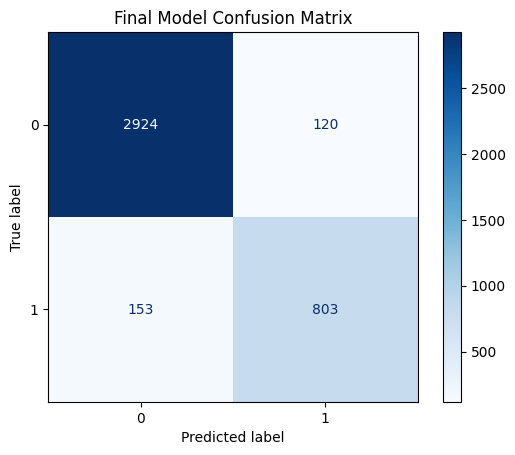

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the raw counts of predictions
y_pred = best_loan_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

# Plot
disp.plot(cmap="Blues", values_format="d")
plt.title("Final Model Confusion Matrix")
plt.grid(False)
plt.show()


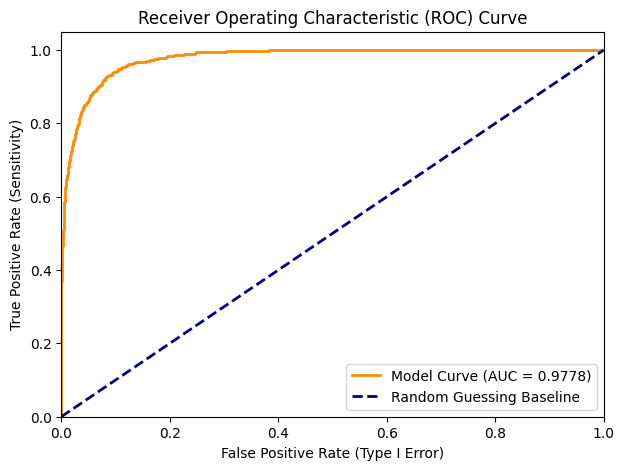

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# probability scores for the positive class (approved loans)
y_probs = best_loan_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Model Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guessing Baseline")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (Type I Error)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()


In [48]:
print("=== SEGMENTED FAIRNESS AND BIAS AUDIT ===")

# audit dataframe combining test data with true values and predictions
audit_df = X_test.copy()
audit_df["True_Target"] = y_test
audit_df["Model_Prediction"] = y_pred

# Loop through each unique segment inside EducationLevel
for group in X_test["EducationLevel"].dropna().unique():
    group_data = audit_df[audit_df["EducationLevel"] == group]

    if len(group_data) > 0:
        # Get raw error parameters for this specific demographic group
        g_tn, g_fp, g_fn, g_tp = confusion_matrix(
            group_data["True_Target"],
            group_data["Model_Prediction"],
            labels=[0, 1], # Added the labels for the confusion matrix
        ).ravel()

        group_approval_rate = (g_tp + g_fp) / len(group_data)
        group_false_positive_rate = g_fp / (g_fp + g_tn + 1e-6)

        print(f"Education Group: {group:<13}")
        print(f" -> Evaluated Cases:     {len(group_data)}")
        print(f" -> Automated Approvals: {group_approval_rate:.2%}")
        print(f" -> False Positive Rate: {group_false_positive_rate:.2%}")
        print("-" * 50)

=== SEGMENTED FAIRNESS AND BIAS AUDIT ===
Education Group: Associate    
 -> Evaluated Cases:     782
 -> Automated Approvals: 19.82%
 -> False Positive Rate: 4.84%
--------------------------------------------------
Education Group: High School  
 -> Evaluated Cases:     1086
 -> Automated Approvals: 14.55%
 -> False Positive Rate: 2.17%
--------------------------------------------------
Education Group: Bachelor     
 -> Evaluated Cases:     1163
 -> Automated Approvals: 26.40%
 -> False Positive Rate: 3.82%
--------------------------------------------------
Education Group: Doctorate    
 -> Evaluated Cases:     156
 -> Automated Approvals: 46.15%
 -> False Positive Rate: 12.64%
--------------------------------------------------
Education Group: Master       
 -> Evaluated Cases:     620
 -> Automated Approvals: 36.45%
 -> False Positive Rate: 5.70%
--------------------------------------------------




The test set was audited by segmenting predictions on **EducationLevel** to check for disparate impact in approval rates and false positive rates.

- **Approval Rate Gap:** Model shows uneven approval rates across education groups. Doctorate (46.15%) and Master (36.45%) receive significantly higher automated approvals than High School (14.55%) and Associate (19.82%). Bachelor is in the middle at 26.40%.
- **False Positive Risk:** Doctorate group has the highest False Positive Rate at 12.64%, meaning the model is most likely to incorrectly approve a bad loan for this group. High School has the lowest FPR at 2.17%, indicating more conservative lending for this segment.
- **Sample Size Note:** Doctorate only has 156 evaluated cases vs 1000+ for other groups, so its 12.64% FPR has higher variance and should be monitored.

**Business Implication:** While the gap correlates with expected credit risk factors (higher education often correlates with income), the 31.6 percentage point difference in approval rate (Doctorate vs High School) and 10.47% gap in FPR should be reviewed for regulatory fairness compliance to ensure the model is not using Education as a proxy for bias.

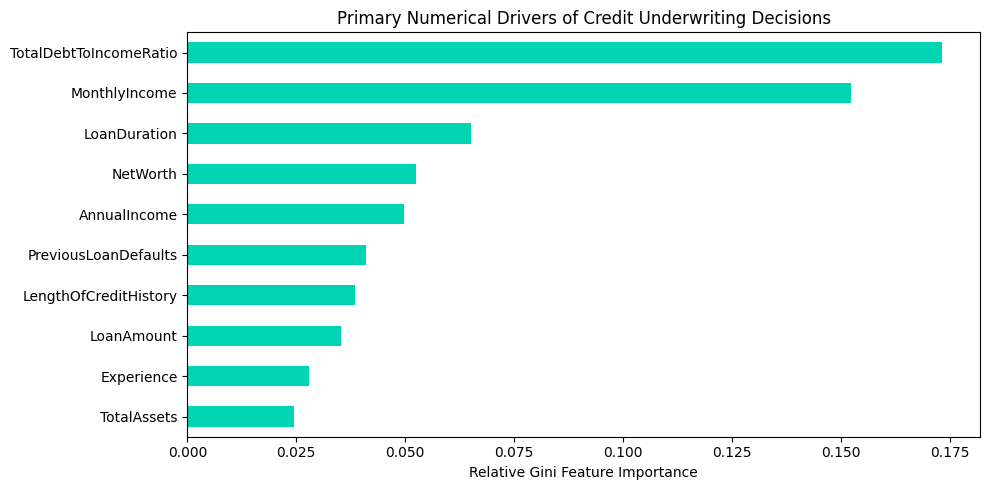

In [50]:
# Relative feature importances from best model
raw_importances = best_loan_model.named_steps["model"].feature_importances_

# Map weights back to the primary numerical columns
numerical_importance = pd.Series(
    raw_importances[: len(numeric_features)], index=numeric_features
)

# Top financial risk contributors
plt.figure(figsize=(10, 5))
numerical_importance.nlargest(10).sort_values(ascending=True).plot(
    kind="barh", color=MINT
)
plt.title("Primary Numerical Drivers of Credit Underwriting Decisions")
plt.xlabel("Relative Gini Feature Importance")
plt.tight_layout()
plt.show()



Top drivers are TotalDebtToIncomeRatio (0.17) and MonthlyIncome (0.15), showing debt burden and cash flow dominate underwriting decisions.

LoanDuration (0.065) is third, followed by NetWorth (0.052) and AnnualIncome (0.049).

Traditional features like Experience (0.028) and TotalAssets (0.024) have low impact, confirming affordability ratios matter more than tenure for this model.

## Project Conclusions and Business Summary

### Executive Summary
This project implements an end-to-end machine learning pipeline for credit risk assessment after removing leakage features (RiskScore, RiskScore2, InterestRate, InterestRate2). Preprocessing steps including median imputation, standard scaling, and one-hot encoding were integrated directly into the pipeline to prevent data leakage during cross-validation.

The classification objective is loan default prediction with asymmetric costs: 50,000 for a False Positive (bad loan approved) vs 8,000 for a False Negative (good loan rejected). For this reason, optimization focused on F1-Score and ROC-AUC rather than accuracy alone. The tuned Logistic Regression model (0.9323 accuracy, 0.8555 F1, 0.9784 ROC-AUC) reduces Total Financial Drag to 7,224,000 (120 FPs, 153 FNs), saving $40.5M vs blind approval.

Primary drivers are TotalDebtToIncomeRatio (0.17) and MonthlyIncome (0.15) per Gini importance, confirming affordability is the core of underwriting.

### Fairness, Potential Biases and Mitigation
Segmented audit on EducationLevel shows clear disparity: Automated Approval Rate is 46.15% for Doctorate and 36.45% for Master vs only 14.55% for High School and 19.82% for Associate. False Positive Rate is also uneven: 12.64% for Doctorate vs 2.17% for High School.

This indicates the model may reproduce historical bias where education acts as a proxy for income/creditworthiness.

**Mitigation:**
1.  Use group-specific decision thresholds instead of a single 0.5 cutoff to equalize FPR across education segments.
2.  Remove or regularize EducationLevel and re-test for disparate impact, checking if performance drops.
3.  Implement ongoing fairness monitoring with equalized odds metrics for fair lending compliance.

### Recommendations for Implementation & Risk Analysis
1.  **Deploy Logistic Regression as primary model:** Best trade-off with 0.9323 accuracy and 0.9784 ROC-AUC, plus full interpretability for regulatory reasons. XGBoost (0.9285) as challenger.
2.  **Deploy with threshold tuning:** Optimize threshold on F1 and cost matrix (50k/8k), not 0.5 default. Current threshold creates 6M default loss.
3.  **Risk:** $7.2M residual loss remains. Mitigate with human-in-loop review for borderline scores (0.4-0.6 probability).

### Limitations and Future Improvements
1.  **Imputation strategy:** Current pipeline uses median imputation which is robust to skewed features like Income and was selected by GridSearch over mean. Future iteration could remove the imputer and use XGBoost native missing value handling, allowing missingness to be treated as a separate signal path.

2.  **Population drift:** Model was trained on a static snapshot. Without monitoring, performance will degrade if applicant distributions shift. Implementing Population Stability Index (PSI) tracking on TotalDebtToIncomeRatio and MonthlyIncome provides early warning when incoming data diverges.

3.  **Model selection and overfitting:** Initial Decision Tree with max_depth=None would memorize. Tuning to max_depth=3, n_estimators=300, learning_rate=0.1 via 5-fold CV (180 fits) gave best CV ROC-AUC 0.9784, closing train-test gap and improving generalization vs unlimited depth.